# Cluster label optimisation

Select the Leiden resolution whose partition best aligns with the `cell_type` weak prior, scored via a **Jaccard / Hungarian** matching procedure: for each resolution, a contingency table between Leiden clusters and cell types is converted to an IoU (Jaccard) matrix, the optimal one-to-one assignment is found with the Hungarian algorithm, and the summed matched Jaccard score is normalised by a denominator that penalises over-clustering when the number of clusters exceeds `k_prior`.

Cells with a `cell_type` label that appears fewer than `MIN_CELLS_PER_TYPE` times are excluded before scoring, keeping the prior reliable.

In [35]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from numpy.typing import NDArray
from scipy.optimize import linear_sum_assignment
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

sc.settings.set_figure_params(dpi=50, facecolor="white")

H5AD_DIR = Path("../data/scbasecount/2026-01-12/h5ad/GeneFull/Homo_sapiens")
FILE_IDX = 2
FILE_SIZE = {0: "75%", 1: "50%", 2: "25%"}
MIN_CELLS_PER_TYPE = 20
N_TOP_GENES = 2000
N_PCS = 40
RESOLUTIONS = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
MERGE_THRESHOLD = 0.30  # lower → more merges; tune toward k_prior

/var/folders/rj/58krw3q53619qt2rbck9wq740000gn/T/ipykernel_52542/3225837933.py:16: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=50, facecolor="white")


## 1. Load & filter rare cell types

### 1.1 Load

In [36]:
h5ad_files = sorted(H5AD_DIR.glob("*.h5ad"))
adata = sc.read(h5ad_files[FILE_IDX])
adata.obs_names_make_unique()

### 1.2 QC

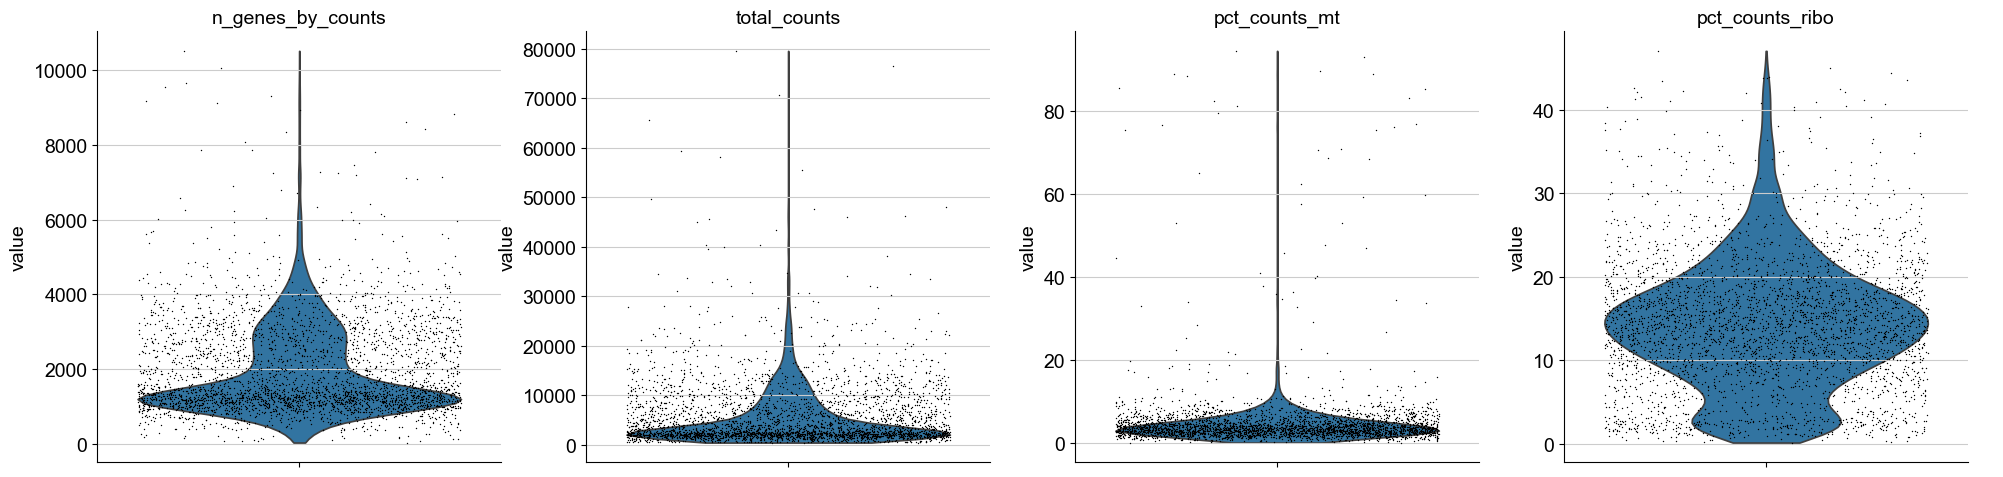

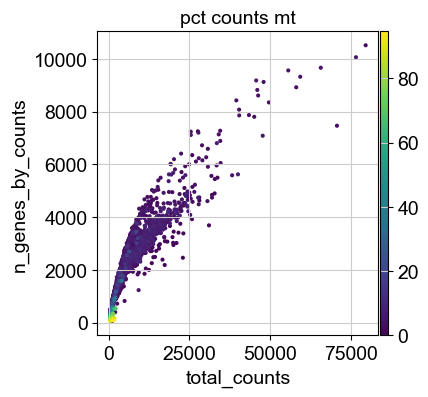

In [37]:
adata.var["mt"] = adata.var["gene_symbols"].str.startswith("MT-")
adata.var["ribo"] = adata.var["gene_symbols"].str.match(r"^RP[SL]\d")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], inplace=True, log1p=False)

sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo"],
    jitter=0.4,
    multi_panel=True,
    show=False,
)
plt.show()

sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt", show=False)
plt.show()

### 1.3 Filter

In [38]:
k_prior = adata.obs["cell_type"].nunique()
type_counts = adata.obs["cell_type"].value_counts()
valid_types = type_counts[type_counts >= MIN_CELLS_PER_TYPE].index
mask = adata.obs["cell_type"].isin(valid_types)
adata = adata[mask].copy()

n_cells_original = adata.n_obs

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(adata)

AnnData object with n_obs × n_vars = 3333 × 22854
    obs: 'gene_count_Unique', 'umi_count_Unique', 'gene_count_UniqueAndMult-EM', 'umi_count_UniqueAndMult-EM', 'gene_count_UniqueAndMult-Uniform', 'umi_count_UniqueAndMult-Uniform', 'SRX_accession', 'cell_type', 'cell_ontology_term_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes'
    var: 'gene_symbols', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    layers: 'UniqueAndMult-EM', 'UniqueAndMult-Uniform'


### 1.4 Normalize

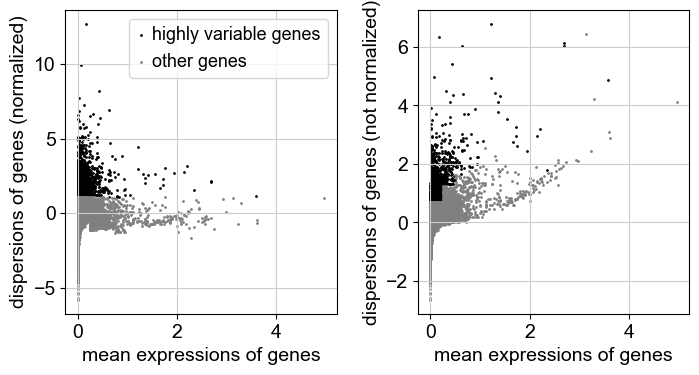

In [39]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata, n_top_genes=N_TOP_GENES)
sc.pl.highly_variable_genes(adata, show=False)
plt.show()

k_filtered = adata.obs["cell_type"].nunique()
n_dropped = n_cells_original - adata.n_obs 

### Summary

In [40]:
print(
    f"Dropped  : {n_dropped} cells ({n_dropped / len(mask):.1%})  "
    f"from types with < {MIN_CELLS_PER_TYPE} cells"
)
print(f"Remaining: {adata.n_obs} cells,  {k_filtered} cell types  (k_prior = {k_prior})")
print("\nExcluded types:")
print(type_counts[type_counts < MIN_CELLS_PER_TYPE].to_string())

Dropped  : 53 cells (1.6%)  from types with < 20 cells
Remaining: 3333 cells,  21 cell types  (k_prior = 26)

Excluded types:
cell_type
bronchial smooth muscle cell       10
vein endothelial cell               8
pericyte                            4
alveolar adventitial fibroblast     4
monocyte                            1


## 2. Dimensionality reduction

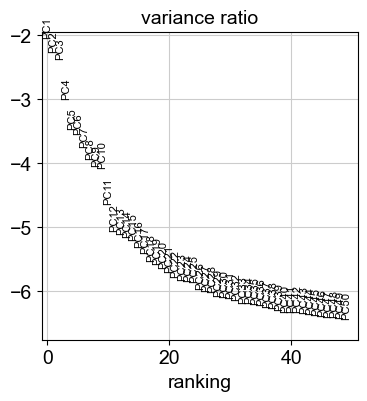

In [41]:
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True, show=False)
plt.show()

In [42]:
sc.pp.neighbors(adata, n_pcs=N_PCS)
sc.tl.umap(adata)

## 3. Resolution sweep

In [43]:
for r in RESOLUTIONS:
    sc.tl.leiden(
        adata, resolution=r, flavor="igraph",
        n_iterations=2, directed=False, key_added=f"leiden_{r}",
    )

n_clusters = {r: adata.obs[f"leiden_{r}"].nunique() for r in RESOLUTIONS}

print(f"k_prior: {k_prior}\n")
print(pd.Series(n_clusters, name="n_clusters").to_string())

k_prior: 26

0.2    13
0.4    15
0.6    15
0.8    18
1.0    18
1.2    20
1.4    21
1.6    23
1.8    25
2.0    25


## 4. Jaccard-based resolution selection

For each resolution, every Leiden cluster is optimally matched 1-to-1 to a cell type using the Hungarian algorithm on the Jaccard similarity matrix. The resolution score is the sum of matched Jaccard values divided by `max(k, k_prior)`.

| Step | Operation |
|---|---|
| 1 | Build contingency table `C[i, j]` = cells in cluster `i` with `cell_type` `j` |
| 2 | Compute `J[i, j] = C[i,j] / (\|cluster_i\| + \|celltype_j\| - C[i,j])` |
| 3 | Optimal 1-to-1 matching via `linear_sum_assignment(-J)` |
| 4 | `score = sum(matched J) / max(k, k_prior)` |

The denominator penalises both extremes: under-clustering (k < k_prior) leaves cell types unmatched; over-clustering (k > k_prior) leaves clusters unmatched. Both pull the score toward zero. The optimum is the resolution where clusters align 1-to-1 with cell types in size and composition.

In [44]:
# Get reference labels (one per cell)
ref_labels = adata.obs["cell_type"].values
# Get unique cell types
celltypes = np.unique(ref_labels)
# Get number of clusters for each resolution
k_arr = np.array([n_clusters[r] for r in RESOLUTIONS])
# Initialise array to store Jaccard scores
jacc_arr = np.zeros(len(RESOLUTIONS))

# Loop through resolutions
for idx, r in enumerate(RESOLUTIONS):
    # Get Leiden labels for current resolution (one per cell)
    leiden_labels = adata.obs[f"leiden_{r}"].values
    # Get unique clusters for current resolution
    clusters = np.unique(leiden_labels)
    # Get number of clusters and cell types
    k, m = len(clusters), len(celltypes)

    # Create mapping of cluster indices to cluster labels and cell type indices to cell type labels
    cl_idx = {c: i for i, c in enumerate(clusters)}
    ct_idx = {t: j for j, t in enumerate(celltypes)}

    # Create contingency table
    C = np.zeros((k, m), dtype=np.float64)
    # Populate contingency table
    for cl, ct in zip(leiden_labels, ref_labels):
        # Increment cell count in contingency table where cluster and cell type meet (intersection)
        C[cl_idx[cl], ct_idx[ct]] += 1

    # Get size of each cluster and cell type
    cl_sizes = C.sum(axis=1)
    ct_sizes = C.sum(axis=0)
    # Compute Jaccard similarity matrix (IoU), prevent division by zero
    J = C / (cl_sizes[:, None] + ct_sizes[None, :] - C + 1e-10)

    # Optimal 1-to-1 matching via Hungarian algorithm (minimize cost: more negative = better)
    row_ind, col_ind = linear_sum_assignment(-J)
    # Sum of Jaccard values of optimal matches
    jacc_arr[idx] = J[row_ind, col_ind].sum()

best_idx = int(np.argmax(jacc_arr))
SELECTED_RESOLUTION = RESOLUTIONS[best_idx]
CLUSTER_KEY = f"leiden_{SELECTED_RESOLUTION}"

print(
    f"Selected resolution : {SELECTED_RESOLUTION}\n"
    f"Clusters (k)        : {n_clusters[SELECTED_RESOLUTION]}\n"
    f"k_prior             : {k_prior}\n"
    f"Jaccard score       : {jacc_arr[best_idx]:.3f}"
)

Selected resolution : 2.0
Clusters (k)        : 25
k_prior             : 26
Jaccard score       : 10.263


### 4.1 Plot Jaccard

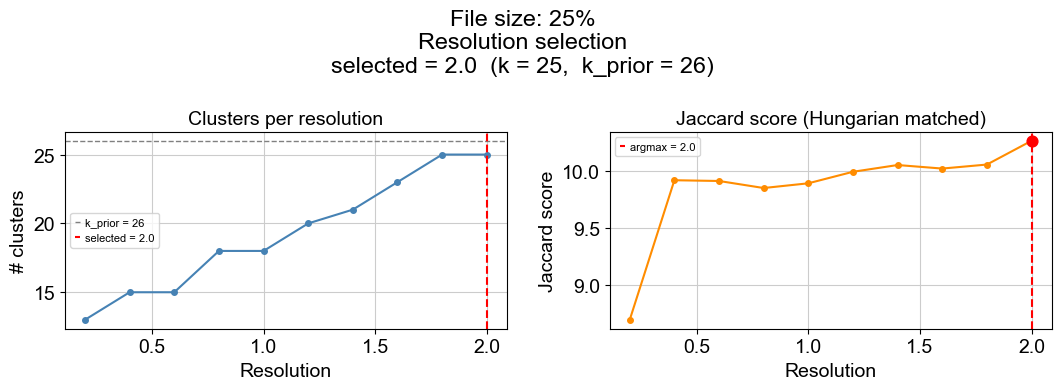

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# panel 1 — k vs resolution
axes[0].plot(RESOLUTIONS, k_arr, marker="o", ms=4, color="steelblue")
axes[0].axhline(k_prior, color="gray", linestyle="--", linewidth=1,
                label=f"k_prior = {k_prior}")
axes[0].axvline(SELECTED_RESOLUTION, color="red", linestyle="--",
                label=f"selected = {SELECTED_RESOLUTION}")
axes[0].set_xlabel("Resolution")
axes[0].set_ylabel("# clusters")
axes[0].set_title("Clusters per resolution")
axes[0].legend(fontsize=8)

# panel 2 — Jaccard score
axes[1].plot(RESOLUTIONS, jacc_arr, marker="o", ms=4, color="darkorange")
axes[1].axvline(SELECTED_RESOLUTION, color="red", linestyle="--",
                label=f"argmax = {SELECTED_RESOLUTION}")
axes[1].scatter(
    [SELECTED_RESOLUTION], [jacc_arr[best_idx]],
    color="red", zorder=5, s=60,
)
axes[1].set_xlabel("Resolution")
axes[1].set_ylabel("Jaccard score")
axes[1].set_title("Jaccard score (Hungarian matched)")
axes[1].legend(fontsize=8)

plt.suptitle(
    f"File size: {FILE_SIZE[FILE_IDX]}\nResolution selection\nselected = {SELECTED_RESOLUTION}  "
    f"(k = {n_clusters[SELECTED_RESOLUTION]},  k_prior = {k_prior})",
    # fontsize=10,
)
plt.tight_layout()
fig.savefig(f".figs/resolution_sweep_file{FILE_IDX}.svg", bbox_inches="tight")
plt.show()

## 5. Visualise selected partition

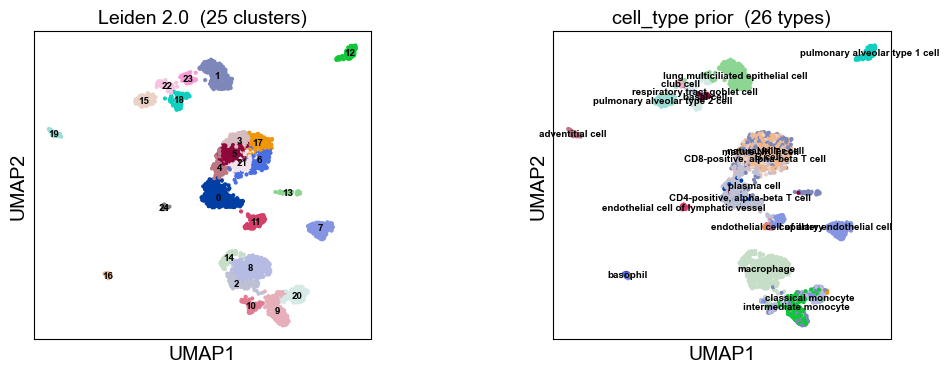

In [46]:
sc.pl.umap(
    adata,
    color=[CLUSTER_KEY, "cell_type"],
    ncols=2,
    legend_loc="on data",
    legend_fontsize=7,
    wspace=0.4,
    title=[
        f"Leiden {SELECTED_RESOLUTION}  ({n_clusters[SELECTED_RESOLUTION]} clusters)",
        f"cell_type prior  ({k_prior} types)",
    ],
    show=False,
)
plt.show()

## 6. RF-based cluster merging

Use this section when the selected Leiden partition is still over-clustered relative to the biological signal. A `RandomForestClassifier` is trained on the selected partition using stratified out-of-fold CV. The row-normalised OOF confusion matrix identifies cluster pairs that are transcriptomically indistinguishable; those pairs are merged via union-find (transitively: if A↔B and B↔C, all three collapse).

Tune `MERGE_THRESHOLD` to adjust the final cluster count toward `k_prior`.

In [47]:
def rf_pairwise_confusion(
    X: NDArray[np.float32],
    cluster_labels: NDArray[np.str_],
    n_estimators: int = 300,
    n_splits: int = 3,
    random_state: int = 42,
) -> tuple[NDArray[np.float64], NDArray]:
    le = LabelEncoder()
    y = le.fit_transform(cluster_labels)
    n_classes = len(le.classes_)
    min_class_size = int(np.bincount(y).min())
    n_splits = min(n_splits, min_class_size)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_preds = np.zeros(len(y), dtype=int)

    for train_idx, test_idx in skf.split(X, y):
        rf = RandomForestClassifier(
            n_estimators=n_estimators, n_jobs=-1, random_state=random_state
        )
        rf.fit(X[train_idx], y[train_idx])
        oof_preds[test_idx] = rf.predict(X[test_idx])

    conf = np.zeros((n_classes, n_classes))
    for true, pred in zip(y, oof_preds):
        conf[true, pred] += 1
    row_sums = conf.sum(axis=1, keepdims=True)
    conf = conf / np.where(row_sums == 0, 1, row_sums)

    return conf, le.classes_


def merge_by_confusion(
    cluster_labels: NDArray[np.str_],
    conf: NDArray[np.float64],
    classes: NDArray,
    threshold: float,
) -> tuple[NDArray[np.str_], dict]:
    n = len(classes)
    parent = list(range(n))

    def find(x: int) -> int:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x: int, y: int) -> None:
        parent[find(x)] = find(y)

    for i in range(n):
        for j in range(i + 1, n):
            if conf[i, j] > threshold or conf[j, i] > threshold:
                union(i, j)

    root_map: dict[int, str] = {}
    counter = 0
    for idx in range(n):
        root = find(idx)
        if root not in root_map:
            root_map[root] = str(counter)
            counter += 1

    label_to_merged = {classes[i]: root_map[find(i)] for i in range(n)}
    merged = np.vectorize(label_to_merged.get)(np.asarray(cluster_labels))
    return merged, label_to_merged

### 6.1 Plot RF cluster merging

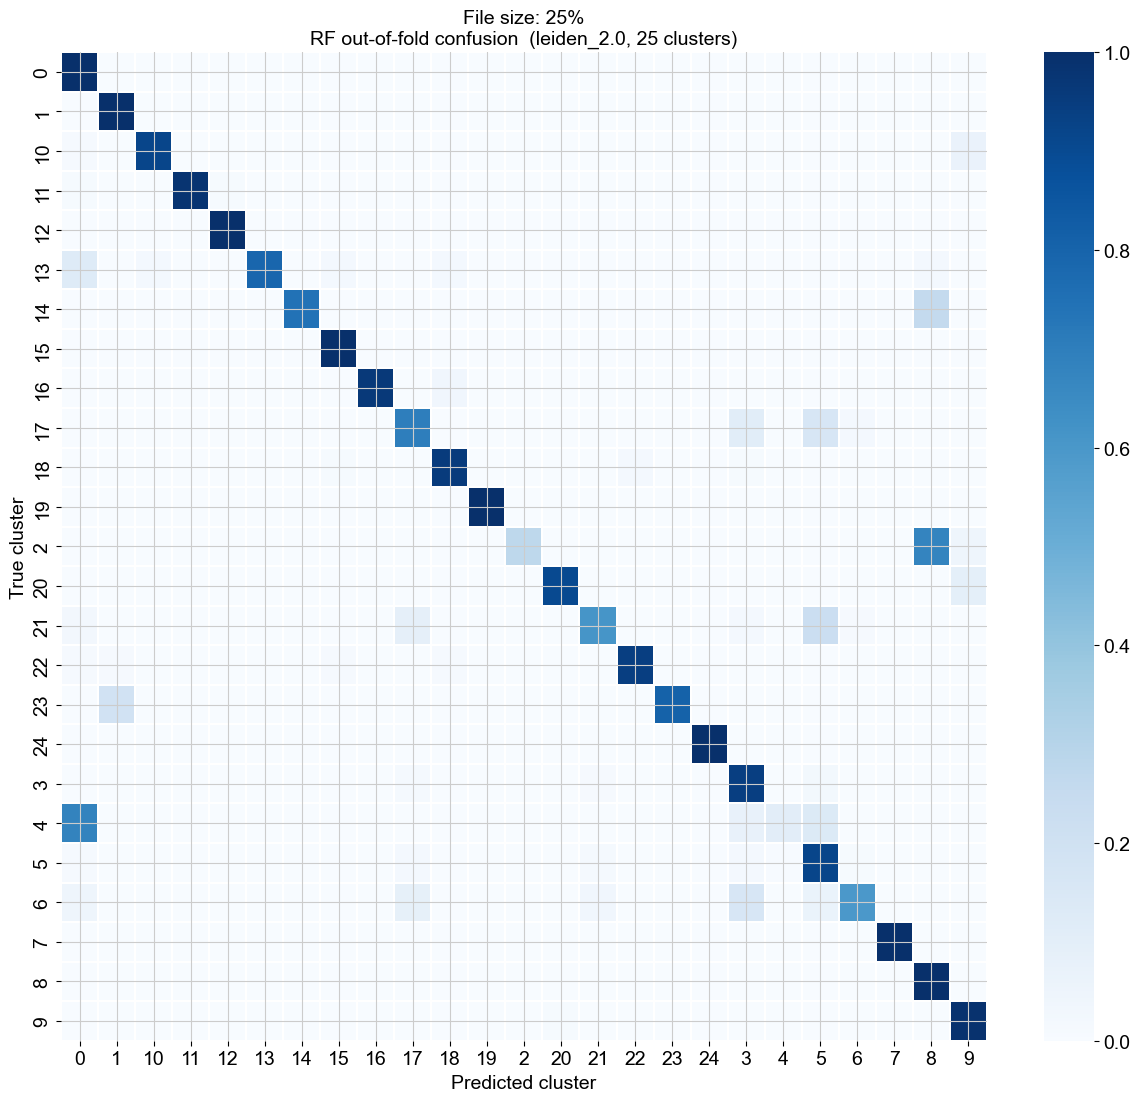

In [48]:
X_hvg = adata.X[:, adata.var.highly_variable.values]
if hasattr(X_hvg, "toarray"):
    X_hvg = X_hvg.toarray()

conf, classes = rf_pairwise_confusion(X_hvg, adata.obs[CLUSTER_KEY].values)

fig, ax = plt.subplots(
    figsize=(max(8, len(classes) * 0.5), max(6, len(classes) * 0.45))
)
sns.heatmap(
    conf,
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    vmin=0, vmax=1,
    ax=ax,
    # annot=len(classes) <= 25,
    fmt=".2f",
    linewidths=0.3,
)
ax.set_xlabel("Predicted cluster")
ax.set_ylabel("True cluster")
ax.set_title(
    f"File size: {FILE_SIZE[FILE_IDX]}\nRF out-of-fold confusion  ({CLUSTER_KEY}, {len(classes)} clusters)"
)
plt.tight_layout()
fig.savefig(f".figs/rf_confusion_file{FILE_IDX}.svg")
plt.show()

### 6.2 Summarize RF merge

In [49]:
merged_labels, label_map = merge_by_confusion(
    adata.obs[CLUSTER_KEY].values, conf, classes, MERGE_THRESHOLD
)
adata.obs["leiden_merged"] = pd.Categorical(merged_labels)

n_merged = adata.obs["leiden_merged"].nunique()
print(
    f"Before merge : {len(classes)} clusters\n"
    f"After merge  : {n_merged} clusters\n"
    f"k_prior      : {k_prior}\n"
)
label_map_series = pd.Series(label_map, name="merged_into")
print(label_map_series.to_string())

# Print which clusters were merged
merged_groups = {}
for original, merged in label_map.items():
    merged_groups.setdefault(merged, []).append(original)
print("\nClusters merged:")
for merged_label, grouped in merged_groups.items():
    if len(grouped) > 1:
        print(f"  {merged_label}: {grouped}")


Before merge : 25 clusters
After merge  : 23 clusters
k_prior      : 26

0      0
1      1
10     2
11     3
12     4
13     5
14     6
15     7
16     8
17     9
18    10
19    11
2     12
20    13
21    14
22    15
23    16
24    17
3     18
4      0
5     19
6     20
7     21
8     12
9     22

Clusters merged:
  0: ['0', '4']
  12: ['2', '8']


## 7. Plot final clustering

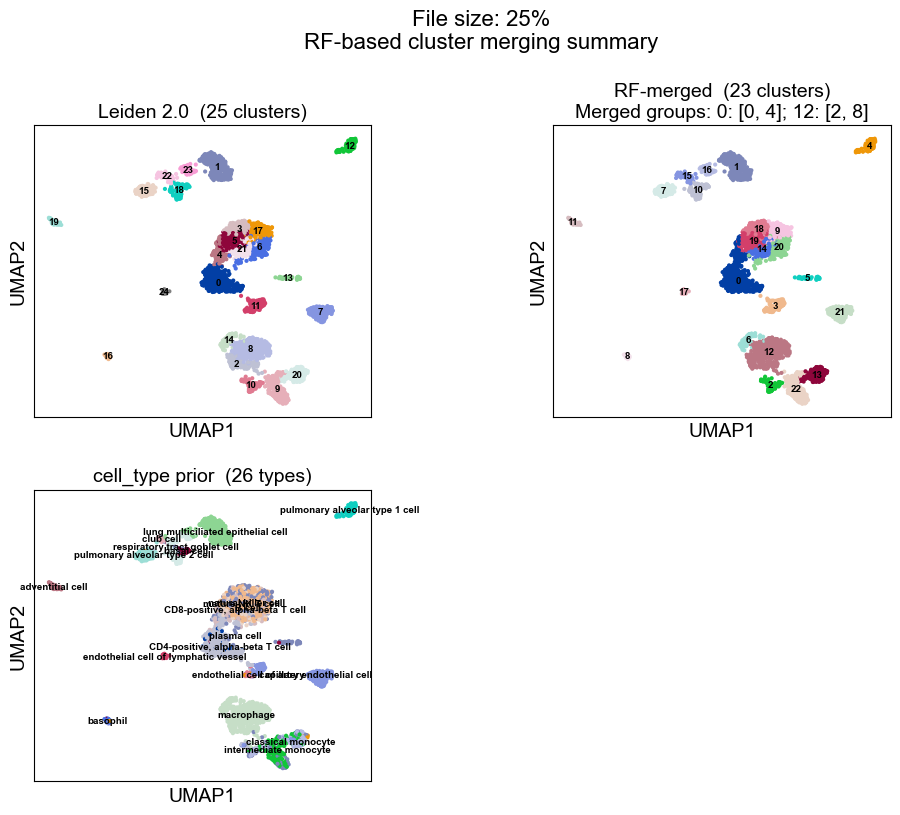

In [50]:
merged_groups_plot = [group for group in merged_groups.values() if len(group) > 1]
if merged_groups_plot:
    merged_groups_str = "; ".join(
        [f"{m}: [{', '.join(map(str, g))}]" for m, g in merged_groups.items() if len(g) > 1]
    )
    umap_merged_title = (
        f"RF-merged  ({n_merged} clusters)\n"
        f"Merged groups: {merged_groups_str}"
    )
else:
    umap_merged_title = f"RF-merged  ({n_merged} clusters)\n(no merges)"
# Regenerate the UMAP plot with merged clusters and new title
fig = sc.pl.umap(
    adata,
    color=[CLUSTER_KEY, "leiden_merged", "cell_type"],
    ncols=2,
    legend_loc="on data",
    legend_fontsize=7,
    wspace=0.4,
    title=[
        f"Leiden {SELECTED_RESOLUTION}  ({len(classes)} clusters)",
        umap_merged_title,
        f"cell_type prior  ({k_prior} types)",
    ],
    show=False,
    return_fig=True,
)
# Add a main title for the whole plot
if fig is not None:
    fig.suptitle(f"File size: {FILE_SIZE[FILE_IDX]}\nRF-based cluster merging summary", fontsize=16, y=1.03)

plt.savefig(f".figs/umap_merged_file{FILE_IDX}.svg", bbox_inches="tight")
plt.show()

### 7.1 Analyze relative cluster size

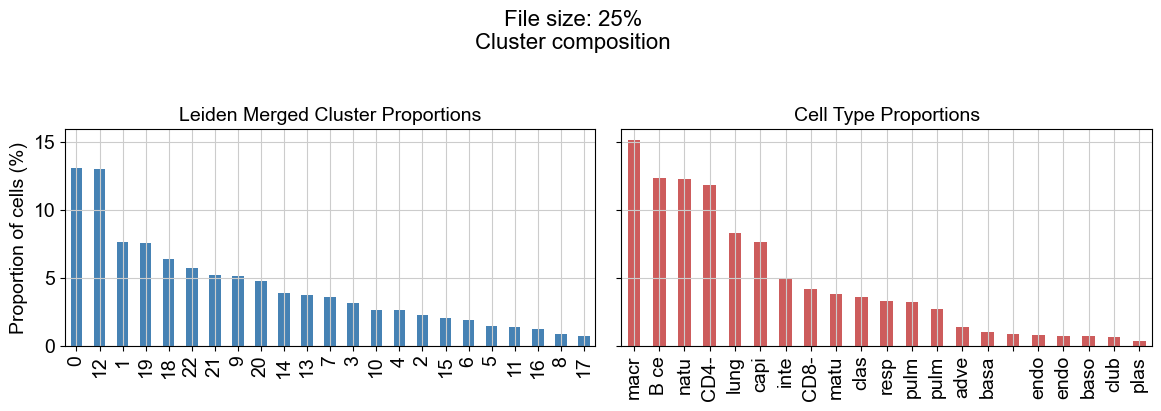

In [51]:
# Calculate normalized value counts and sort by size (descending)
merged_counts = adata.obs["leiden_merged"].value_counts(normalize=True).sort_values(ascending=False) * 100
celltype_counts = adata.obs["cell_type"].value_counts(normalize=True).sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
merged_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Leiden Merged Cluster Proportions")
axes[0].set_ylabel("Proportion of cells (%)")
axes[0].set_xlabel("")
# Show x ticks, limit each label to 4 characters
axes[0].set_xticks(range(len(merged_counts)))
axes[0].set_xticklabels([str(lbl)[:4] for lbl in merged_counts.index], rotation=90)

celltype_counts.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title("Cell Type Proportions")
axes[1].set_xlabel("")
axes[1].set_xticks(range(len(celltype_counts)))
axes[1].set_xticklabels([str(lbl)[:4] for lbl in celltype_counts.index], rotation=90)

fig.suptitle(f"File size: {FILE_SIZE[FILE_IDX]}\nCluster composition", fontsize=16, y=1.03)

plt.tight_layout()
fig.savefig(f".figs/composition_bars_file{FILE_IDX}.svg", bbox_inches="tight")
plt.show()